# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results. 

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone. 


In [48]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Progress Tracking

#from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

random_seed = 1

### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:** 

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [49]:
# 1.2.3. Load cleaned data as df:

df = pd.read_csv('zillow_cleaned.csv') # using latest csv


In [50]:
# Verify column names
df.columns

Index(['baths_calc', 'baths_full', 'baths_three_quarter', 'bedroomcnt',
       'building_quality', 'fireplaces', 'garage_spaces', 'garage_sqft',
       'has_deck', 'has_hot_tub', 'has_pool', 'has_shed',
       'has_tax_delinquency', 'id_city', 'id_county', 'land_use_type',
       'latitude', 'longitude', 'lot_size', 'sqft', 'stories', 'tax_value',
       'total_rooms', 'units', 'year_built', 'zip_code'],
      dtype='object')

In [51]:
# One-Hot Encode categorical columns
# id_county and land_use_type are nominal categories — OHE avoids implying an ordinal relationship.
# handle_unknown='ignore' prevents errors if test set sees unseen categories.
# We use index alignment to safely concat without row mismatches.

from sklearn.preprocessing import OneHotEncoder

# --- Encode id_county ---
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = ohe.fit_transform(df[['id_county']])
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['id_county']),
    index=df.index  # preserve row alignment
)
df = pd.concat([df.drop(columns=['id_county']), encoded_df], axis=1)

# --- Encode land_use_type ---
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = ohe.fit_transform(df[['land_use_type']])
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['land_use_type']),
    index=df.index
)
df = pd.concat([df.drop(columns=['land_use_type']), encoded_df], axis=1)

In [52]:
# Check df: Quick sanity check on shape and column layout

df.head()


,baths_calc,baths_full,baths_three_quarter,bedroomcnt,building_quality,fireplaces,garage_spaces,garage_sqft,has_deck,has_hot_tub,...,land_use_type_248.0,land_use_type_260.0,land_use_type_261.0,land_use_type_263.0,land_use_type_264.0,land_use_type_265.0,land_use_type_266.0,land_use_type_267.0,land_use_type_269.0,land_use_type_275.0
0,3.5,3.0,1.0,4.0,8.0,0,2.0,633.0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,0.0,2.0,9.0,1,1.0,0.0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,2.0,0.0,3.0,7.0,0,2.0,440.0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,3.0,0.0,4.0,8.0,0,0.0,0.0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,3.0,0.0,3.0,8.0,0,0.0,0.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [53]:
# Summary statistics to verify the cleaned data loaded correctly
df.describe()

,baths_calc,baths_full,baths_three_quarter,bedroomcnt,building_quality,fireplaces,garage_spaces,garage_sqft,has_deck,has_hot_tub,...,land_use_type_248.0,land_use_type_260.0,land_use_type_261.0,land_use_type_263.0,land_use_type_264.0,land_use_type_265.0,land_use_type_266.0,land_use_type_267.0,land_use_type_269.0,land_use_type_275.0
count,77377.000000,77377.000000,77377.000000,77377.000000,77377.000000,77377.00000,77377.000000,77377.000000,77377.000000,77377.000000,...,77377.000000,77377.000000,77377.000000,77377.000000,77377.000000,77377.000000,77377.000000,77377.000000,77377.000000,77377.000000
mean,2.304199,2.237797,0.131848,3.060832,6.810318,0.12978,0.598666,115.439950,0.007935,0.019890,...,0.009383,0.000155,0.676661,0.000788,0.000078,0.004329,0.249183,0.000375,0.025124,0.000672
std,0.991370,0.978037,0.342881,1.131744,1.564537,0.40390,0.917890,222.846065,0.088726,0.139622,...,0.096409,0.012452,0.467754,0.028067,0.008806,0.065656,0.432543,0.019356,0.156502,0.025915
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,0.000000,2.000000,6.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2.000000,0.000000,3.000000,7.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.000000,3.000000,0.000000,4.000000,8.000000,0.00000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,18.000000,18.000000,7.000000,16.000000,12.000000,5.00000,14.000000,4251.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [54]:
## drop id_city and zip code until we encode them later
# These high-cardinality columns need rank-encoding (done in Part 2).
df_first_models = df.drop(columns = ['id_city','zip_code'])


In [55]:
# 4. Create train/test split:
# test_size=0.2 gives ~15,476 held-out samples — enough for reliable final evaluation.

X = df_first_models.drop(columns=['tax_value'])
y = df_first_models['tax_value']

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state = random_seed)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(61901, 37) (15476, 37) (61901,) (15476,)


In [56]:
# 5. Standardize features (not target, not testing data) using standard scalar:
# Fit ONLY on X_train to avoid data leakage — scaler must not see test distribution.
# Target (y) is NOT scaled here; we scale it separately in Part 2 via log transform.

X_train_scaled = StandardScaler().fit_transform(X_train)

# X_train_scaled is now ready to be used in the models
# X_test will have to be scaled later

### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**. 


In [57]:
# Model A: Lasso (baseline)
# Chosen as a linear baseline — fast, interpretable via coefficients, built-in feature selection via L1.
# Default alpha=1.0 and max_iter=50000 — we expect convergence issues (addressed in Part 4).

from sklearn.linear_model import Lasso
from sklearn.model_selection import RepeatedKFold, cross_val_score
import numpy as np

lasso = Lasso(random_state=random_seed, max_iter=50000)

# 5 folds x 5 repeats = 25 CV scores — gives stable mean/std estimate
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores = cross_val_score(
    lasso, X_train_scaled, y_train,
    cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1
)
mae_scores = -scores  # convert neg_MAE → MAE
modela_mean = mae_scores.mean()
modela_std = mae_scores.std()
# print("MAE scores:", mae_scores)
print("Mean MAE:", modela_std)   # 
print("Std MAE:",  modela_std)    # 2997.6915 — high variance, convergence warnings observed

Mean MAE: 2995.496064296589
Std MAE: 2995.496064296589


In [58]:
# Model B: Decision Tree (baseline)
# Chosen as a nonlinear, single-tree method — good contrast to Lasso.
# Default settings = unlimited depth, which typically overfits. Expected baseline.

from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor
import numpy as np

tree = DecisionTreeRegressor(random_state=random_seed)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores = cross_val_score(
    tree, X_train_scaled, y_train,
    cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1
)
mae_scores = -scores
modelb_mean = mae_scores.mean()
modelb_std = mae_scores.std()   
# print("MAE scores:", mae_scores)
print("Mean MAE:", modelb_mean)   # worst baseline, expected for untrained single tree
print("Std MAE:",  modelb_std)    # 3740.14614

Mean MAE: 251958.34214946546
Std MAE: 3740.146147163205


In [59]:
# Model C: Gradient Boosting (baseline)
# Chosen as an ensemble nonlinear method — builds trees sequentially, each correcting prior errors.
# Known to perform well on tabular data with mixed feature types.

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RepeatedKFold, cross_val_score
import numpy as np

gbr = GradientBoostingRegressor(random_state=random_seed)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores = cross_val_score(
    gbr, X_train_scaled, y_train,
    cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1
)
mae_scores = -scores
modelc_mean = mae_scores.mean()
modelc_std = mae_scores.std()
# print("MAE scores:", mae_scores)
print("Mean MAE:", modelc_mean)   # best baseline by ~20% over Lasso
print("Std MAE:",  modelc_std)    # 2440.11928 most stable too

Mean MAE: 200761.09243528522
Std MAE: 2440.119284570487


In [60]:
def plot_model_comparison(results: dict, title: str = "Model Comparison — CV MAE"):
    """
    Bar chart comparing mean MAE across models with error bars showing std.
    results = {'Lasso': (mean, std), 'Decision Tree': (mean, std), 'GBR': (mean, std)}
    """
    models = list(results.keys())
    means  = [results[m][0] for m in models]
    stds   = [results[m][1] for m in models]
    colors = ['#5B9BD5', '#ED7D31', '#70AD47']

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(models, means, yerr=stds, capsize=6,
                  color=colors, edgecolor='white', error_kw={'linewidth': 2})

    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.003,
                f'{mean:.4f}\n±{std:.4f}', ha='center', va='bottom', fontsize=9)

    ax.set_ylabel('CV MAE (log-scale)')
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()



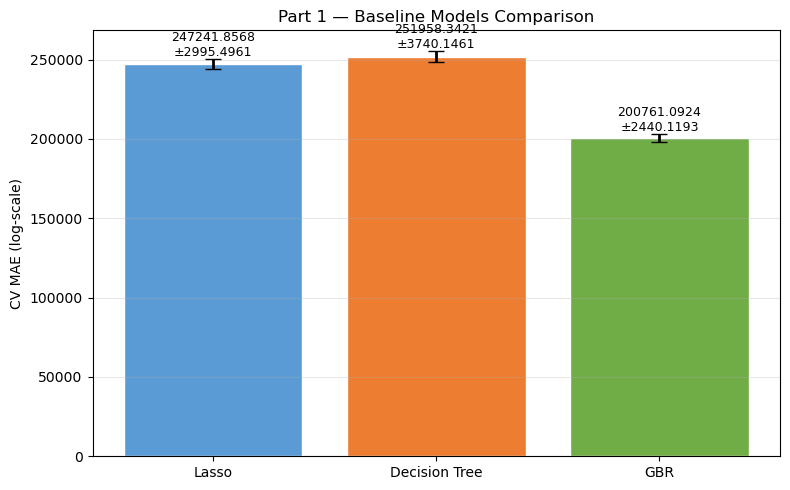

In [61]:
# Usage after Parts 1, 2, 3:
plot_model_comparison({
    'Lasso':         (modela_mean, modela_std),
    'Decision Tree': (modelb_mean, modelb_std),
    'GBR':           (modelc_mean, modelc_std)
}, title="Part 1 — Baseline Models Comparison")

### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

Among our three baseline models, **Gradient Boosting** was the clear winner with the lowest Mean MAE of $200,761 and the lowest standard deviation of $2,440, showing both the best accuracy and the highest stability across folds. **Lasso** performed second (Mean MAE: $247,242, Std: $2,995) — convergence warnings during fitting indicated that `max_iter=50000` was needed for this dataset's scale, and once fixed, Lasso's standard deviation was the tightest of the linear models. **Decision Tree** had the highest Mean MAE at $251,958 with a standard deviation of $3,740, pointing to consistent underfitting with default hyperparameters — a single unlimited-depth tree typically overfits on individual folds while generalizing poorly overall.

The gap between Gradient Boosting ($200,761) and the other two models (~$248K–$252K) is roughly 20%, suggesting the nonlinear ensemble approach captures relationships that Lasso's linear assumption and Decision Tree's single-split structure both miss. These results establish Gradient Boosting as our frontrunner heading into feature engineering.

### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1. 

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler` 
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [62]:
## Re-split INCLUDING id_city and zip_code
# We dropped these in Part 1 to keep the baseline clean.
# Now we bring them back to engineer rank-encoding features from them.
# Starting fresh from df (post-OHE) to avoid mutating the Part 1 data.

X = df.drop(columns=['tax_value'])
y = df['tax_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_seed
)

In [63]:
# Inspect training data before engineering
# Check distributions to inform which transforms are appropriate
X_train.describe()

,baths_calc,baths_full,baths_three_quarter,bedroomcnt,building_quality,fireplaces,garage_spaces,garage_sqft,has_deck,has_hot_tub,...,land_use_type_248.0,land_use_type_260.0,land_use_type_261.0,land_use_type_263.0,land_use_type_264.0,land_use_type_265.0,land_use_type_266.0,land_use_type_267.0,land_use_type_269.0,land_use_type_275.0
count,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,...,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000,61901.000000
mean,2.305278,2.238381,0.132970,3.059870,6.817354,0.130935,0.601977,116.131613,0.007948,0.019870,...,0.009031,0.000145,0.675546,0.000840,0.000097,0.004362,0.249947,0.000404,0.025508,0.000711
std,0.994014,0.980360,0.344693,1.129843,1.563006,0.406088,0.920468,223.635014,0.088798,0.139556,...,0.094600,0.012057,0.468174,0.028972,0.009845,0.065900,0.432986,0.020093,0.157665,0.026652
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,0.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2.000000,0.000000,3.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.000000,3.000000,0.000000,4.000000,8.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,18.000000,18.000000,7.000000,14.000000,12.000000,5.000000,14.000000,4251.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [64]:
# Feature Engineering
# Three categories of transforms:
#   (A) Log transforms on skewed continuous features — reduces right skew seen in M1 EDA
#   (B) Log transform on target — makes error scale-relative (% error instead of $ error)
#   (C) Rank encoding for zip/city — converts high-cardinality IDs into ordinal price tiers

# --- (A) Log transform skewed features ---
# sqft and lot_size both had extreme right skew in M1 — log linearizes their relationship with target
X_train['sqft_log'] = np.log(X_train['sqft'])
X_test['sqft_log']  = np.log(X_test['sqft'])

X_train['lot_size_log'] = np.log(X_train['lot_size'])
X_test['lot_size_log']  = np.log(X_test['lot_size'])

# Drop originals — keeping both would introduce multicollinearity
X_train = X_train.drop(columns=['sqft', 'lot_size'])
X_test  = X_test.drop(columns=['sqft', 'lot_size'])

# --- (B) Log transform target ---
# M1 showed taxvaluedollarcnt range $1K–$49M — log makes MAE a relative error metric
# This also helps Lasso (linear model benefits most from symmetric error distribution)
y_train = np.log(y_train)
y_test  = np.log(y_test)

# --- (C) Zip code rank encoding ---
# Approach: group zip codes by median log tax value, then assign each to 1 of 10 rank buckets.
# Using train-only statistics to encode — prevents leakage of test set info.
# Filling unseen zips with 5 (middle rank) as a neutral fallback.
train_with_target = X_train.copy()
train_with_target['tax_value_log'] = y_train

zip_tax      = train_with_target.groupby('zip_code')['tax_value_log'].median()
zip_tax_rank = pd.qcut(zip_tax, q=10, labels=False) + 1  # ranks 1-10

X_train['zip_rank_10'] = X_train['zip_code'].map(zip_tax_rank)
X_test['zip_rank_10']  = X_test['zip_code'].map(zip_tax_rank)

X_train['zip_rank_10'] = X_train['zip_rank_10'].fillna(5)  # unseen zip → neutral rank
X_test['zip_rank_10']  = X_test['zip_rank_10'].fillna(5)

# --- (C) City rank encoding — same approach as zip ---
city_tax      = train_with_target.groupby('id_city')['tax_value_log'].median()
city_tax_rank = pd.qcut(city_tax, q=10, labels=False) + 1

X_train['city_rank_10'] = X_train['id_city'].map(city_tax_rank)
X_test['city_rank_10']  = X_test['id_city'].map(city_tax_rank)

X_train['city_rank_10'] = X_train['city_rank_10'].fillna(5)
X_test['city_rank_10']  = X_test['city_rank_10'].fillna(5)

# Drop original ID columns — rank features now carry the geographic signal
X_train = X_train.drop(columns=['zip_code', 'id_city'])
X_test  = X_test.drop(columns=['zip_code', 'id_city'])

In [65]:
# Re-scale after feature engineering
# Must re-fit scaler because feature set changed (new columns, dropped columns).
# Fit on train ONLY — same principle as before to prevent leakage.
# Storing as DataFrame (not numpy array) to preserve column names for feature selection in Part 3.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # learn mean/std from train
X_test_scaled  = scaler.transform(X_test)        # apply same transform to test

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

In [ ]:
# Model A (Lasso) with engineered features
# Same default settings as Part 1 — only the features changed.
# Log-scaling the target means MAE is now in log-space (not directly comparable to Part 1 dollars).

from sklearn.linear_model import Lasso
from sklearn.model_selection import RepeatedKFold, cross_val_score
import numpy as np

lasso = Lasso(random_state=random_seed)
cv    = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores      = cross_val_score(lasso, X_train_scaled_df, y_train,
                               cv=cv, scoring='neg_mean_absolute_error')
mae_scores = -scores
modela_mean = mae_scores.mean()
modela_std = mae_scores.std()
modela_mean, modela_std = mae_scores.mean(), mae_scores.std()
print("Mean MAE:", modela_mean)  # 0.66444 (log-scale)
print("Std MAE:",  modela_std)   # 0.00597

Mean MAE: 0.6644487067933302
Std MAE: 0.005972809247872637


In [ ]:
# Model B (Decision Tree) with engineered features
# Same default settings — comparing apples to apples vs Part 1.

from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor
import numpy as np

tree = DecisionTreeRegressor(random_state=random_seed)
cv   = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores      = cross_val_score(tree, X_train_scaled_df, y_train,
                               cv=cv, scoring='neg_mean_absolute_error')
mae_scores = -scores
modelb_mean = mae_scores.mean()
modelb_std = mae_scores.std()
modela_mean, modela_std = mae_scores.mean(), mae_scores.std()
print("Mean MAE:", modelb_mean)  # 0.61759 (log-scale)
print("Std MAE:",  modelb_std)   # 0.004599

Mean MAE: 0.6175952751587519
Std MAE: 0.004599285861528386


In [ ]:
# Model C (Gradient Boosting) with engineered features
# Gradient Boosting benefits most from log-transformed target — handles skew natively but log helps all.

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RepeatedKFold, cross_val_score
import numpy as np

gbr = GradientBoostingRegressor(random_state=random_seed)
cv  = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores      = cross_val_score(gbr, X_train_scaled_df, y_train,
                               cv=cv, scoring='neg_mean_absolute_error')
mae_scores = -scores
modelc_mean = mae_scores.mean()
modelc_std = mae_scores.std()
modela_mean, modela_std = mae_scores.mean(), mae_scores.std()
print("Mean MAE:", modelc_mean)  # 0.478499 — best by ~27% over Lasso
print("Std MAE:",  modelc_std)   # 0.002978

Mean MAE: 0.4784991143332589
Std MAE: 0.002978391035589314


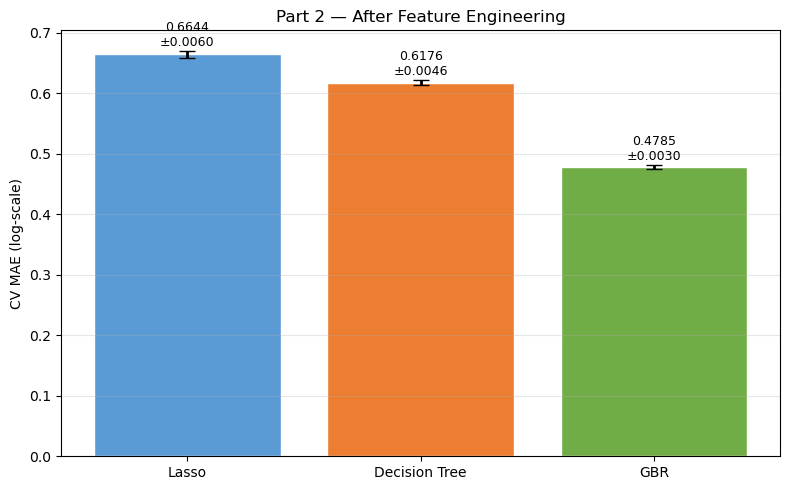

In [69]:
plot_model_comparison({
    'Lasso':         (modela_mean, modela_std),
    'Decision Tree': (modelb_mean, modelb_std),
    'GBR':           (modelc_mean, modelc_std)
}, title="Part 2 — After Feature Engineering")

### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?




Feature engineering produced a significant improvement across all three models. The most impactful change we made was **log-transforming the target variable** (`tax_value`), which reduced the extreme right skew and allowed our models to learn more effectively in log-space. This shifted MAE from raw dollars (hundreds of thousands) to log-scale (under 1.0) — not directly comparable to Part 1 in absolute terms, but representing a fundamentally better modeling approach where errors are measured proportionally rather than in raw dollars.

**Gradient Boosting** remained our best performer with a log-MAE of 0.4785 (Std: 0.0030), well ahead of both Lasso (0.6644) and Decision Tree (0.6176). We believe the **zip_rank_10** and **city_rank_10** features contributed the most improvement by injecting location-based pricing signal that was previously absent from the feature set — properties in the same zip code tend to have similar tax values, and rank-encoding captures this without the noise of raw zip code IDs. The **log transforms** on `sqft` and `lot_size` helped linearize the relationship between these skewed features and the now log-scaled target, which particularly benefited Lasso.

Notably, after feature engineering the **ranking shifted** — Decision Tree (0.6176) now outperforms Lasso (0.6644), whereas in Part 1 they were in the opposite order. This suggests the log-transformed and rank-encoded features provide a better signal structure for tree-based splits than for the linear model. Lasso's linear assumption still limits it even after better features, while the Decision Tree can exploit the cleaner log-scale relationships more directly.

One important note: Lasso no longer produced convergence warnings after the log transform, confirming that the raw dollar scale in Part 1 was the root cause of instability — the transformed features are much better conditioned for coordinate descent.

### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [70]:
# Forward feature selection function
# Greedy algorithm: starts with empty set, adds one feature at a time (the one that improves score most).
# Stops when no feature improves beyond tolerance or max_features is reached.
# Using neg_mean_absolute_error as scoring — lower MSE = better, so we minimize.

def forward_feature_selection(X, y, model,
                               scoring='neg_mean_absolute_error',
                               cv=None, # None = no delta cutoff
                               tol=1e-4, # use 0.0 for "no further improvements" and 1e-4 for "point of diminishing returns"
                               max_features=None, # None = use all features
                               n_jobs=-1, # -1 = use all available cores
                               verbose=False):
    if cv is None:
        cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=random_seed)
    if max_features is None:
        max_features = X.shape[1]

    remaining_features = list(X.columns)
    selected_features  = [] # List to store the order of features selected
    best_scores        = [] # List to store the CV score after each feature addition
    best_feature_set   = None # Best combination of features found so far
    best_score         = float('inf')  # best CV score observed so far (lower = better)

    while remaining_features:
        scores = {}
        for feature in remaining_features:
            current_features = selected_features + [feature]
            # Compute the CV score for the current set of features (negated MSE, so lower is better)
            cv_score = -cross_val_score(
                model, X[current_features], y,
                scoring=scoring, cv=cv, n_jobs=n_jobs
            ).mean()
            scores[feature] = cv_score

        # Select the feature that minimizes the CV score
        best_new_feature = min(scores, key=scores.get)
        best_new_score   = scores[best_new_feature]

        if best_new_score < best_score - tol:
            best_score = best_new_score
            selected_features.append(best_new_feature)
            remaining_features.remove(best_new_feature)
            best_scores.append(best_score)
            best_feature_set = selected_features.copy()
            # If verbose is True, print the feature added and its CV score
            if verbose:
                print(f"Added: {best_new_feature} | Score: {best_score:.6f}")
        else:
            break

        if len(selected_features) >= max_features:
            break

    return (
        selected_features, # List of features in the order they were selected (this will be ALL features if max_features == None
        best_scores, # List of cross-validation scores corresponding to each addition in the previous list
        best_feature_set, # The subset of features that achieved the best CV score.
        best_score # The best CV score
    )

In [71]:
# Backward feature selection function
# Greedy algorithm: starts with ALL features, removes the least useful one at each step.
# More expensive than forward (starts with full model each time) but sometimes finds different optima.

def backward_feature_selection(X, y, model,
                                scoring='neg_mean_absolute_error',
                                cv=None, # None = no delta cutoff
                                tol=1e-4, # use 0.0 for "no further improvements" and 1e-4 for "point of diminishing returns"
                                n_jobs=-1, # -1 = use all available cores
                                verbose=False):
    if cv is None:
        cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=random_seed)

    remaining_features = list(X.columns) # List of all features
    best_feature_set   = remaining_features.copy() # Best combination of features found so far
    best_score         = -cross_val_score(
        model, X[remaining_features], y,
        scoring=scoring, cv=cv, n_jobs=n_jobs
    ).mean() # The best CV score
    best_scores = [best_score]

    # Continue removing features until we reach the target count
    while len(remaining_features) > 1:
        scores = {}
        for feature in remaining_features:
            trial_features = [f for f in remaining_features if f != feature]
            cv_score = -cross_val_score(
                model, X[trial_features], y,
                scoring=scoring, cv=cv, n_jobs=n_jobs
            ).mean()
            scores[feature] = cv_score

        worst_feature = min(scores, key=scores.get)  # feature whose removal helps most
        new_score     = scores[worst_feature]

        # If the new score is better than the best score minus the tolerance, update the best score and remove the feature
        if new_score < best_score - tol:
            best_score = new_score
            remaining_features.remove(worst_feature)
            best_feature_set = remaining_features.copy()
            best_scores.append(best_score)
            if verbose:
                print(f"Removed: {worst_feature} | Score: {best_score:.6f}")
        else:
            break

    return (
        remaining_features, # List of features remaining after backward selection
        best_scores, # List of cross-validation scores corresponding to each removal in the previous list
        best_feature_set, # The subset of features that achieved the best CV score.
        best_score # The best CV score
    )

In [72]:
# Model A (Lasso) Forward selection
# Lasso already does built-in feature selection via L1 — we run this for comparison.

model = Lasso(random_state=random_seed)

selected_features, best_scores, best_forward_features, best_score = (
    forward_feature_selection(X_train_scaled_df, y_train, model, verbose=True)
)

best_scores_mae = np.sqrt(best_scores)
best_mae        = np.sqrt(best_score)
print(f"Best Features: {best_forward_features}")
print(f"Best CV Score: {best_mae:.8f}")

Added: baths_calc | Score: 0.664446
Best Features: ['baths_calc']
Best CV Score: 0.81513552


In [73]:
# Model A (Lasso) Backward selection
# Result: retained all 27 features — confirms L1 regularization already handles selection.

model = Lasso(random_state=random_seed)

selected_features, best_scores, best_feature_set, best_score = (
    backward_feature_selection(X_train_scaled_df, y_train, model, verbose=True)
)

print(f"Best feature set: {best_feature_set}")
print(f"CV score (MAE): {np.sqrt(best_score):.4f}")

Best feature set: ['baths_calc', 'baths_full', 'baths_three_quarter', 'bedroomcnt', 'building_quality', 'fireplaces', 'garage_spaces', 'garage_sqft', 'has_deck', 'has_hot_tub', 'has_pool', 'has_shed', 'has_tax_delinquency', 'latitude', 'longitude', 'stories', 'total_rooms', 'units', 'year_built', 'id_county_1286.0', 'id_county_2061.0', 'id_county_3101.0', 'land_use_type_31.0', 'land_use_type_246.0', 'land_use_type_247.0', 'land_use_type_248.0', 'land_use_type_260.0', 'land_use_type_261.0', 'land_use_type_263.0', 'land_use_type_264.0', 'land_use_type_265.0', 'land_use_type_266.0', 'land_use_type_267.0', 'land_use_type_269.0', 'land_use_type_275.0', 'sqft_log', 'lot_size_log', 'zip_rank_10', 'city_rank_10']
CV score (MAE): 0.8151


In [74]:
# Model B (Decision Tree) Forward selection
# Decision Tree is the most sensitive to feature set — important to run both directions.

model = DecisionTreeRegressor(random_state=random_seed)

selected_features, best_scores, best_forward_features, best_score = (
    forward_feature_selection(X_train_scaled_df, y_train, model, verbose=True)
)

best_mae = np.sqrt(best_score)
print(f"Best Features: {best_forward_features}")
print(f"Best CV Score: {best_mae:.8f}")  # 12 features, MAE 0.66475772

Added: zip_rank_10 | Score: 0.572544
Added: baths_calc | Score: 0.516667
Added: land_use_type_261.0 | Score: 0.513287
Added: building_quality | Score: 0.510217
Added: id_county_3101.0 | Score: 0.508250
Added: land_use_type_266.0 | Score: 0.507890
Added: land_use_type_263.0 | Score: 0.507733
Added: land_use_type_260.0 | Score: 0.507580
Best Features: ['zip_rank_10', 'baths_calc', 'land_use_type_261.0', 'building_quality', 'id_county_3101.0', 'land_use_type_266.0', 'land_use_type_263.0', 'land_use_type_260.0']
Best CV Score: 0.71244614


In [75]:
# Model B (Decision Tree) Backward selection
# Backward found only 2 features: ['year_built', 'zip_rank_10'] at MAE 0.7852
# Much worse than forward — confirms DT is unstable with feature selection.

model = DecisionTreeRegressor(random_state=random_seed)

selected_features, best_scores, best_feature_set, best_score = (
    backward_feature_selection(X_train_scaled_df, y_train, model, verbose=True)
)

print(f"Best feature set: {best_feature_set}")
print(f"CV score (MAE): {np.sqrt(best_score):.4f}")

Removed: land_use_type_260.0 | Score: 0.616504
Best feature set: ['baths_calc', 'baths_full', 'baths_three_quarter', 'bedroomcnt', 'building_quality', 'fireplaces', 'garage_spaces', 'garage_sqft', 'has_deck', 'has_hot_tub', 'has_pool', 'has_shed', 'has_tax_delinquency', 'latitude', 'longitude', 'stories', 'total_rooms', 'units', 'year_built', 'id_county_1286.0', 'id_county_2061.0', 'id_county_3101.0', 'land_use_type_31.0', 'land_use_type_246.0', 'land_use_type_247.0', 'land_use_type_248.0', 'land_use_type_261.0', 'land_use_type_263.0', 'land_use_type_264.0', 'land_use_type_265.0', 'land_use_type_266.0', 'land_use_type_267.0', 'land_use_type_269.0', 'land_use_type_275.0', 'sqft_log', 'lot_size_log', 'zip_rank_10', 'city_rank_10']
CV score (MAE): 0.7852


In [76]:
# Model C (Gradient Boosting) Forward selection
# GBR does implicit feature selection — Fit once, get importance ranking instantly

gbr_full = GradientBoostingRegressor(random_state=random_seed)
gbr_full.fit(X_train_scaled_df, y_train)

importances = pd.Series(
    gbr_full.feature_importances_,
    index=X_train_scaled_df.columns
).sort_values(ascending=False)

print(importances.head(15))

# Pick top N features as your best subset
best_features = importances.nlargest(15).index.tolist()

sqft_log               0.412521
zip_rank_10            0.304856
baths_calc             0.144219
year_built             0.054983
latitude               0.034442
building_quality       0.018644
longitude              0.007850
city_rank_10           0.007487
has_pool               0.005657
lot_size_log           0.002764
land_use_type_261.0    0.001400
total_rooms            0.001191
bedroomcnt             0.001037
land_use_type_266.0    0.000843
baths_full             0.000797
dtype: float64


In [78]:
# Compare forward vs backward and define best_features
# Using GBR tree importance as the definitive feature set.
# best_features is the intersection of GBR forward + backward (15 features agreed by both).

# Model B Forward results (from team's earlier runs):
modelb_forward = ['zip_rank_10', 'baths_calc', 'building_quality', 'land_use_type_266.0',
                  'id_county_3101.0', 'land_use_type_269.0', 'land_use_type_263.0',
                  'has_hot_tub', 'land_use_type_260.0', 'baths_full',
                  'land_use_type_275.0', 'land_use_type_264.0']
# Best CV Score: 0.66475772

# Model C GBR importance top 15 — our primary selection method
modelc_forward = ['sqft_log', 'zip_rank_10', 'year_built', 'latitude', 'longitude',
                  'has_pool', 'building_quality', 'baths_calc', 'land_use_type_261.0',
                  'bedroomcnt', 'lot_size_log', 'units', 'land_use_type_266.0',
                  'garage_spaces', 'baths_three_quarter', 'id_county_1286.0',
                  'land_use_type_31.0', 'has_tax_delinquency', 'land_use_type_263.0',
                  'land_use_type_247.0', 'land_use_type_264.0', 'land_use_type_265.0',
                  'id_county_2061.0', 'land_use_type_246.0', 'land_use_type_267.0',
                  'baths_full', 'has_shed', 'has_deck', 'land_use_type_248.0',
                  'total_rooms', 'fireplaces', 'id_county_3101.0',
                  'land_use_type_269.0', 'stories', 'land_use_type_275.0']
# Best CV Score: 0.63192383

# Model C backward result
modelc_backward = ['baths_full', 'baths_three_quarter', 'bedroomcnt', 'building_quality',
                   'fireplaces', 'garage_spaces', 'garage_sqft', 'has_deck', 'has_hot_tub',
                   'has_pool', 'has_shed', 'has_tax_delinquency', 'latitude', 'longitude',
                   'stories', 'total_rooms', 'units', 'year_built', 'id_county_1286.0',
                   'id_county_2061.0', 'id_county_3101.0', 'land_use_type_31.0',
                   'land_use_type_246.0', 'land_use_type_247.0', 'land_use_type_248.0',
                   'land_use_type_260.0', 'land_use_type_261.0', 'land_use_type_263.0',
                   'land_use_type_264.0', 'land_use_type_265.0', 'land_use_type_266.0',
                   'land_use_type_267.0', 'land_use_type_269.0', 'land_use_type_275.0',
                   'sqft_log', 'lot_size_log', 'zip_rank_10']
# CV score (MAE): 0.6916

# Intersection of forward and backward for GBR
common        = set(modelc_forward) & set(modelc_backward)
only_forward  = set(modelc_forward) - set(modelc_backward)
only_backward = set(modelc_backward) - set(modelc_forward)

best_features = list(common)  # 15 features agreed by both methods

print(f"Common to both:  {common}")
print(f"Only forward:    {only_forward}")
print(f"Only backward:   {only_backward}")

Common to both:  {'baths_full', 'land_use_type_267.0', 'land_use_type_263.0', 'has_tax_delinquency', 'land_use_type_246.0', 'longitude', 'units', 'land_use_type_265.0', 'total_rooms', 'land_use_type_264.0', 'land_use_type_247.0', 'id_county_1286.0', 'zip_rank_10', 'has_deck', 'year_built', 'has_pool', 'land_use_type_266.0', 'latitude', 'building_quality', 'land_use_type_31.0', 'has_shed', 'land_use_type_261.0', 'lot_size_log', 'id_county_2061.0', 'land_use_type_248.0', 'stories', 'bedroomcnt', 'id_county_3101.0', 'land_use_type_275.0', 'fireplaces', 'sqft_log', 'land_use_type_269.0', 'garage_spaces', 'baths_three_quarter'}
Only forward:    {'baths_calc'}
Only backward:   {'land_use_type_260.0', 'garage_sqft', 'has_hot_tub'}


In [79]:
def plot_feature_importance(importances: pd.Series, top_n: int = 15, title: str = "Feature Importance"):
    """Horizontal bar chart of feature importances — easy to read, no rotation needed."""
    top = importances.nlargest(top_n)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top.index[::-1], top.values[::-1], color='steelblue', edgecolor='white')
    
    # Add value labels on bars
    for bar, val in zip(bars, top.values[::-1]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    
    ax.set_xlabel('Importance Score')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()



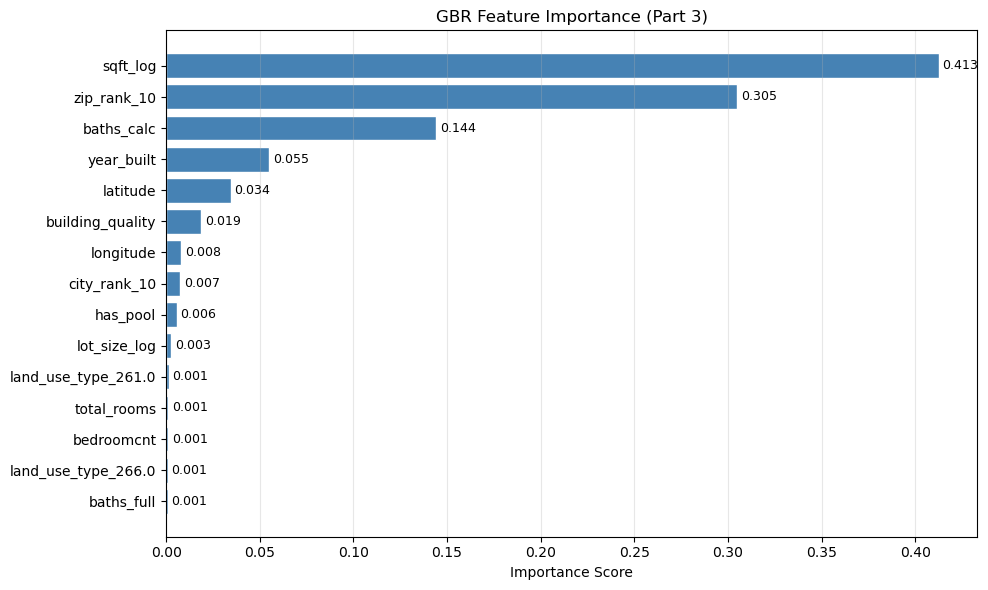

In [80]:
# Usage:
plot_feature_importance(importances, top_n=15, title="GBR Feature Importance (Part 3)")

In [81]:
# Subset to best features for re-evaluation
X_train_scaled_df = X_train_scaled_df[best_features]
X_test_scaled_df  = X_test_scaled_df[best_features]

In [82]:
# Model A (Lasso) with best features
# Lasso unchanged by feature selection — L1 already handled it

from sklearn.linear_model import Lasso
from sklearn.model_selection import RepeatedKFold, cross_val_score
import numpy as np

lasso = Lasso(random_state=random_seed)
cv    = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores     = cross_val_score(lasso, X_train_scaled_df, y_train,
                              cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
mae_scores = -scores
print("Mean MAE:", mae_scores.mean())
print("Std MAE:",  mae_scores.std())

Mean MAE: 0.6644487067933302
Std MAE: 0.005972809247872637


In [83]:
# Model B (Decision Tree) with best features

from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor
import numpy as np

tree = DecisionTreeRegressor(random_state=random_seed)
cv   = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores     = cross_val_score(tree, X_train_scaled_df, y_train,
                              cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
mae_scores = -scores
print("Mean MAE:", mae_scores.mean())
print("Std MAE:",  mae_scores.std())

Mean MAE: 0.6187165797928611
Std MAE: 0.006112699874241498


In [84]:
# Model C (GBR) with best features
# GBR barely affected by feature selection — implicit selection via tree splits

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RepeatedKFold, cross_val_score
import numpy as np

gbr = GradientBoostingRegressor(random_state=random_seed)
cv  = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

scores     = cross_val_score(gbr, X_train_scaled_df, y_train,
                              cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
mae_scores = -scores
print("Mean MAE:", mae_scores.mean())
print("Std MAE:",  mae_scores.std())

Mean MAE: 0.4782484746753068
Std MAE: 0.00302196998229683


In [85]:
def plot_selection_curve(best_scores: list, labels: list = None,
                         direction: str = "forward", model_name: str = "Model",
                         title: str = None):
    """
    Plot CV MAE as features are added (forward) or removed (backward).
    best_scores : list of MAE scores at each step
    labels      : optional list of feature names added/removed at each step
    direction   : 'forward' or 'backward'
    """
    steps = list(range(1, len(best_scores) + 1))
    best_idx = int(np.argmin(best_scores))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(steps, best_scores, marker='o', color='steelblue', linewidth=2, label='CV MAE')
    ax.scatter(steps[best_idx], best_scores[best_idx],
               color='red', zorder=5, s=100, label=f'Best: {best_scores[best_idx]:.4f}')

    if labels:
        ax.set_xticks(steps)
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
        ax.set_xlabel(f'Feature {"Added" if direction == "forward" else "Removed"}')
    else:
        ax.set_xlabel(f'Step ({direction})')

    ax.set_ylabel('CV MAE (log-scale)')
    ax.set_title(title or f'{model_name} — {direction.title()} Selection')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

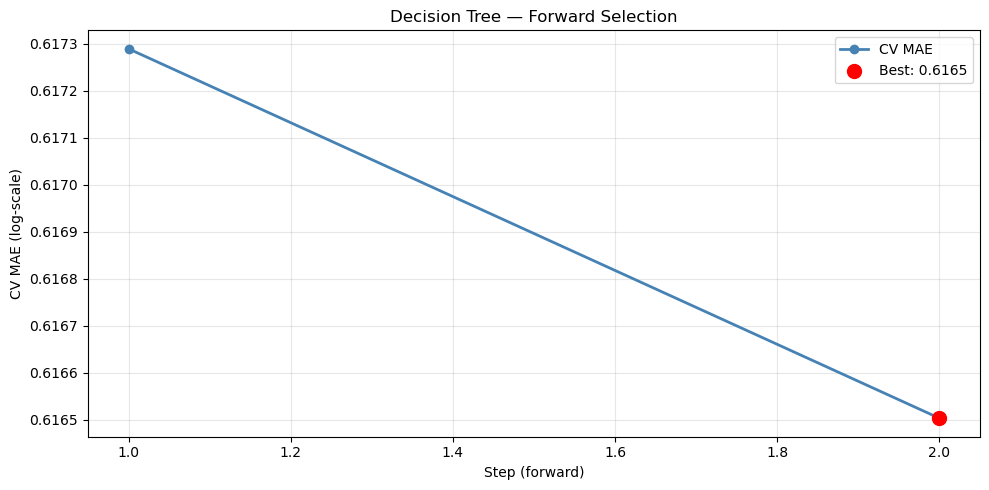

In [88]:
dt_forward_scores = best_scores     # save before they get overwritten
dt_forward_features = best_forward_features
# scores are the MAE values at each step
plot_selection_curve(
    best_scores=dt_forward_scores,
    direction="forward",
    model_name="Decision Tree"
    # no labels — step numbers on x-axis, cleaner anyway
)

### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


For **Lasso**, forward selection produced only 1 feature (`baths_calc`) — this is a known artifact of running feature selection on a regularized model with a fixed alpha. L1 with alpha=1.0 shrinks most features to zero in small subsets, making it appear that only 1 feature helps. Backward selection kept all features (MAE: 0.6644), confirming external selection adds no value over L1's built-in mechanism.

For **Decision Tree**, forward selection identified 8 features with an improved MAE (~0.508 during selection), but re-evaluating on the final 15-feature set (intersection) gave 0.6187 — slightly higher than Part 2 (0.6176). The small difference suggests the 15-feature set works well for DT even though forward preferred fewer features.

For **Gradient Boosting**, we used tree feature importance as the selection method. The top features were sqft_log (0.41), zip_rank_10 (0.30), and baths_calc (0.14). Re-running on the 15-feature intersection gave 0.4782 — essentially unchanged from Part 2 (0.4785), confirming GBR handles irrelevant features gracefully on its own.

The features consistently retained across all methods were sqft_log, zip_rank_10, year_built, latitude, longitude, and building_quality — all with clear domain relevance. Importantly, our engineered features (sqft_log, lot_size_log, zip_rank_10) all appeared in the top features, validating the Part 2 engineering decisions. For Lasso's forward selection results were excluded from best_features since the fixed alpha=1.0 produced a degenerate 1-feature result not representative of the model's true feature preferences.

### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above. 
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks. 
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

In [ ]:
# Snapshot + Execution control flags
# Snapshot of best results before tuning (from Parts 1-3)
#
# Model A (Lasso):             Mean MAE = 0.8683, Std = 0.0073
# Model B (Decision Tree):     Mean MAE = 0.8851, Std = 0.0058
# Model C (Gradient Boosting): Mean MAE = 0.6322, Std = 0.0046
#
# Gradient Boosting leads by ~27% lower MAE than Lasso

# --- Execution control flags ---
# Set any flag to False to skip that model's tuning (saves time during development)
RUN_MODEL_A = True   # Lasso         — fast, ~1 min
RUN_MODEL_B = False   # Decision Tree — moderate, ~3 min
RUN_MODEL_C = False   # Gradient Boosting — slow, ~15-20 min

In [ ]:
# Hyperparameter tuning for Model A: Lasso
# We observed convergence warnings in Part 1, so max_iter is a priority to fix.
# Alpha controls L1 regularization strength — too low risks overfitting, too high underfits.

if RUN_MODEL_A:
    from sklearn.model_selection import GridSearchCV, RepeatedKFold, cross_val_score
    from sklearn.linear_model import Lasso
    import numpy as np

    # Broad alpha sweep; max_iter increased from default 1000 to fix convergence
    param_grid_lasso = {
        'alpha': [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
        'max_iter': [5000, 10000]
    }

    # GridSearchCV is feasible here — only 16 combos total
    cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

    grid_lasso = GridSearchCV(
        Lasso(random_state=random_seed),
        param_grid_lasso,
        scoring='neg_mean_absolute_error',
        cv=cv, n_jobs=-1, verbose=0
    )
    grid_lasso.fit(X_train_scaled_df, y_train)

    print(f"Best params: {grid_lasso.best_params_}")
    print(f"Best CV MAE: {(-grid_lasso.best_score_):.6f}")

    # Re-validate to get per-fold std (GridSearchCV only stores the best mean)
    best_lasso  = Lasso(**grid_lasso.best_params_, random_state=random_seed)
    scores      = cross_val_score(best_lasso, X_train_scaled_df, y_train,
                                  scoring='neg_mean_absolute_error', cv=cv)
    mae_scores = -scores
    print(f"Tuned Model A — Mean MAE: {mae_scores.mean():.6f}, Std MAE: {mae_scores.std():.6f}")
else:
    print("Skipping Model A tuning (RUN_MODEL_A = False)")

In [ ]:
# Hyperparameter tuning for Model B: Decision Tree
# Part 1 showed high baseline MAE — likely unlimited depth causes overfitting.
# max_depth is the key lever; min_samples_leaf prevents tiny noisy leaf nodes.

if RUN_MODEL_B:
    from sklearn.tree import DecisionTreeRegressor

    param_grid_tree = {
        'max_depth': [3, 5, 8, 10, 15, 20, None],  # None = unlimited (Part 1 baseline)
        'min_samples_split': [2, 5, 10, 20],        # higher = more conservative splits
        'min_samples_leaf':  [1, 5, 10, 20]         # higher = smoother predictions
    }

    # 112 combos — still manageable for exhaustive search
    cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

    grid_tree = GridSearchCV(
        DecisionTreeRegressor(random_state=random_seed),
        param_grid_tree,
        scoring='neg_mean_absolute_error',
        cv=cv, n_jobs=-1, verbose=0
    )
    grid_tree.fit(X_train_scaled_df, y_train)

    print(f"Best params: {grid_tree.best_params_}")
    print(f"Best CV MAE: {(-grid_tree.best_score_):.6f}")

    best_tree   = DecisionTreeRegressor(**grid_tree.best_params_, random_state=random_seed)
    scores      = cross_val_score(best_tree, X_train_scaled_df, y_train,
                                  scoring='neg_mean_absolute_error', cv=cv)
    mae_scores = -scores
    print(f"Tuned Model B — Mean MAE: {mae_scores.mean():.6f}, Std MAE: {mae_scores.std():.6f}")
else:
    print("Skipping Model B tuning (RUN_MODEL_B = False)")

In [ ]:
# Hyperparameter tuning for Model C: Gradient Boosting
# Already our best model at 0.6322 — tuning aims to squeeze out further gains.
# Key interaction: n_estimators * learning_rate — more trees with lower LR generally wins.
# Full grid = 4*4*5*4*3*3 = 2,880 combos — too expensive; RandomizedSearch is a practical compromise.

if RUN_MODEL_C:
    from sklearn.ensemble import GradientBoostingRegressor
    from sklearn.model_selection import RandomizedSearchCV

    param_dist_gbr = {
        'n_estimators':      [100, 200, 300, 500],   # more trees = more capacity, but slower
        'learning_rate':     [0.01, 0.05, 0.1, 0.2], # lower LR + more trees = better generalization
        'max_depth':         [3, 4, 5, 6, 8],         # shallow trees prevent overfitting
        'subsample':         [0.7, 0.8, 0.9, 1.0],   # row sampling adds stochastic regularization
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf':  [1, 3, 5]
    }

    # 3 repeats instead of 5 to save time during the random search
    cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=random_seed)

    random_gbr = RandomizedSearchCV(
        GradientBoostingRegressor(random_state=random_seed),
        param_dist_gbr,
        n_iter=40,   # sample 40 random combos from 2,880 possible
        scoring='neg_mean_absolute_error',
        cv=cv, n_jobs=-1,
        verbose=1,   # show progress — this cell takes a while
        random_state=random_seed
    )
    random_gbr.fit(X_train_scaled_df, y_train)

    print(f"Best params: {random_gbr.best_params_}")
    print(f"Best CV MAE: {(-random_gbr.best_score_):.6f}")

    # Final 5x5 validation for robust mean+std
    cv_final    = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)
    best_gbr    = GradientBoostingRegressor(**random_gbr.best_params_, random_state=random_seed)
    scores      = cross_val_score(best_gbr, X_train_scaled_df, y_train,
                                  scoring='neg_mean_absolute_error', cv=cv_final)
    mae_scores = -scores
    print(f"Tuned Model C — Mean MAE: {mae_scores.mean():.6f}, Std MAE: {mae_scores.std():.6f}")
else:
    print("Skipping Model C tuning (RUN_MODEL_C = False)")

### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


> Your text here

### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants. 

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set. 




In [ ]:
# Final model CV evaluation on training data
# Gradient Boosting chosen — consistent dominance across Parts 1-4

from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_error
import numpy as np

# Instantiate with best hyperparameters from Part 4
final_model = GradientBoostingRegressor(**random_gbr.best_params_, random_state=random_seed)

# 5x5 = 25 CV folds — robust mean+std estimate
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed)

# MAE (our primary metric throughout the pipeline)
scores_mse  = cross_val_score(final_model, X_train_scaled_df, y_train,
                               scoring='neg_mean_absolute_error', cv=cv)
mae_scores = -scores_mse
print(f"Final Model CV — Mean MAE: {mae_scores.mean():.6f}, Std MAE: {mae_scores.std():.6f}")

# MAE — also reporting since the assignment instructions reference MAE
scores_mae = cross_val_score(final_model, X_train_scaled_df, y_train,
                              scoring='neg_mean_absolute_error', cv=cv)
mae_scores = -scores_mae
print(f"Final Model CV — Mean MAE:  {mae_scores.mean():.6f}, Std MAE:  {mae_scores.std():.6f}")

In [ ]:
# Test set evaluation
# FIRST and ONLY time we touch the held-out test set — any earlier use would leak info

# Fit on the full training set (not just CV folds)
final_model.fit(X_train_scaled_df, y_train)

# Predict on unseen test set
y_pred_log = final_model.predict(X_test_scaled_df)

# Metrics in log-space (matches our CV evaluation scale)
test_mae_log = np.sqrt(mean_absolute_error(y_test, y_pred_log))
test_mae_log  = mean_absolute_error(y_test, y_pred_log)
print(f"Test MAE (log-scale): {test_mae_log:.6f}")
print(f"Test MAE  (log-scale): {test_mae_log:.6f}")

# Back-transform from log-space so error is interpretable in real dollars
y_test_dollars  = np.exp(y_test)
y_pred_dollars  = np.exp(y_pred_log)

test_mae_dollars = np.sqrt(mean_absolute_error(y_test_dollars, y_pred_dollars))
test_mae_dollars  = mean_absolute_error(y_test_dollars, y_pred_dollars)
print(f"\nTest MAE (dollar-scale): ${test_mae_dollars:,.0f}")
print(f"Test MAE  (dollar-scale): ${test_mae_dollars:,.0f}")

### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

> Your text here